In [2]:
import os

for dirname, _, filenames in os.walk("/kaggle/input"):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/ramyakondru/diagnosed-cbc-data-csv/diagnosed_cbc_data_v4.csv


In [3]:
import pandas as pd

df = pd.read_csv(
    "/kaggle/input/datasets/ramyakondru/diagnosed-cbc-data-csv/diagnosed_cbc_data_v4.csv"
)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (1281, 15)


,WBC,LYMp,NEUTp,LYMn,NEUTn,RBC,HGB,HCT,MCV,MCH,MCHC,PLT,PDW,PCT,Diagnosis
0,10.0,43.2,50.1,4.3,5.0,2.77,7.3,24.2,87.7,26.3,30.1,189.0,12.5,0.17,Normocytic hypochromic anemia
1,10.0,42.4,52.3,4.2,5.3,2.84,7.3,25.0,88.2,25.7,20.2,180.0,12.5,0.16,Normocytic hypochromic anemia
2,7.2,30.7,60.7,2.2,4.4,3.97,9.0,30.5,77.0,22.6,29.5,148.0,14.3,0.14,Iron deficiency anemia
3,6.0,30.2,63.5,1.8,3.8,4.22,3.8,32.8,77.9,23.2,29.8,143.0,11.3,0.12,Iron deficiency anemia
4,4.2,39.1,53.7,1.6,2.3,3.93,0.4,316.0,80.6,23.9,29.7,236.0,12.8,0.22,Normocytic hypochromic anemia


## Define the Anemia Classification Scope

The dataset contains multiple hematological conditions, including anemia,
leukemia, and thrombocytopenia.

For this project, the model is designed to distinguish healthy CBC patterns
from different anemia classes. Therefore, leukemia and thrombocytopenia-related
records are excluded from the anemia-specific classification model.

The selected target classes are:

- Healthy
- Normocytic hypochromic anemia
- Normocytic normochromic anemia
- Iron deficiency anemia
- Other microcytic anemia
- Macrocytic anemia

In [4]:
anemia_classes = [
    "Healthy",
    "Normocytic hypochromic anemia",
    "Normocytic normochromic anemia",
    "Iron deficiency anemia",
    "Other microcytic anemia",
    "Macrocytic anemia"
]

anemia_df = df[df["Diagnosis"].isin(anemia_classes)].copy()

print("Anemia-specific dataset shape:", anemia_df.shape)
print("\nClass distribution:")
print(anemia_df["Diagnosis"].value_counts())

Anemia-specific dataset shape: (1150, 15)

Class distribution:
Diagnosis
Healthy                           336
Normocytic hypochromic anemia     279
Normocytic normochromic anemia    269
Iron deficiency anemia            189
Other microcytic anemia            59
Macrocytic anemia                  18
Name: count, dtype: int64


## Duplicate Record Removal

Exact duplicate CBC records are identified and removed before model training.

Duplicate samples may bias model evaluation if identical patient records appear
in both the training and testing datasets. Removing exact duplicates helps
produce a more reliable evaluation of the anemia classification model.

In [5]:
duplicate_count = anemia_df.duplicated().sum()

anemia_df = anemia_df.drop_duplicates().reset_index(drop=True)

print("Duplicate records removed:", duplicate_count)
print("Dataset shape after duplicate removal:", anemia_df.shape)

Duplicate records removed: 45
Dataset shape after duplicate removal: (1105, 15)


## Removal of Invalid and Corrupted CBC Records

CBC parameters were inspected for physiologically impossible values,
extreme formatting errors, and internally inconsistent measurements.

Records containing clearly corrupted values in Hemoglobin (HGB),
Hematocrit (HCT), Mean Cell Volume (MCV), Mean Cell Hemoglobin (MCH),
Neutrophil Percentage (NEUTp), and Red Blood Cell count (RBC) were removed.

The consistency between HGB, HCT, and MCHC was also examined for records
with observed HCT measurements. Records showing severe internal
inconsistencies were removed rather than manually correcting values,
as the original measurements could not be reliably verified.

In [6]:
anemia_df = anemia_df[
    (anemia_df["HGB"] > 0) &
    (anemia_df["HGB"] <= 20) &
    (anemia_df["HCT"] <= 100) &
    (anemia_df["MCV"] > 0) &
    (anemia_df["MCH"] <= 100) &
    (anemia_df["NEUTp"] <= 100) &
    (anemia_df["RBC"] <= 10)
].reset_index(drop=True)

print("Dataset shape after invalid value removal:", anemia_df.shape)

Dataset shape after invalid value removal: (1091, 15)


### Removal of Internally Inconsistent CBC Records

The consistency between Hemoglobin (HGB), Hematocrit (HCT), and Mean
Corpuscular Hemoglobin Concentration (MCHC) was examined for records
containing observed HCT measurements.

MCHC is related to HGB and HCT, so large differences between the reported
MCHC and the value derived from these measurements can indicate corrupted
or inconsistent CBC records.

Records showing severe internal inconsistencies were removed. Since the
original measurements could not be reliably identified or corrected,
manual modification of individual blood parameters was avoided.

In [7]:
observed_hct = anemia_df[anemia_df["HCT"] != 46.1526].copy()

observed_hct["Calculated_MCHC"] = (
    observed_hct["HGB"] / observed_hct["HCT"]
) * 100

invalid_mchc_indices = observed_hct[
    abs(observed_hct["MCHC"] - observed_hct["Calculated_MCHC"]) > 10
].index

anemia_df = anemia_df.drop(
    index=invalid_mchc_indices
).reset_index(drop=True)

print("Internally inconsistent records removed:", len(invalid_mchc_indices))
print("Final cleaned dataset shape:", anemia_df.shape)

Internally inconsistent records removed: 11
Final cleaned dataset shape: (1080, 15)


In [8]:
anemia_df["Diagnosis"].value_counts()

Diagnosis
Healthy                           321
Normocytic hypochromic anemia     264
Normocytic normochromic anemia    251
Iron deficiency anemia            177
Other microcytic anemia            51
Macrocytic anemia                  16
Name: count, dtype: int64

## Feature Selection

Inspection of the published dataset revealed repeated fixed values across
several features, indicating that some columns may have been pre-imputed
before the dataset was released.

To reduce the model's dependence on potential preprocessing artifacts, the
anemia classifier uses core CBC parameters that showed natural measurement
variation in the dataset.

The selected input features are:

- WBC
- RBC
- HGB
- MCV
- MCH
- MCHC
- PLT

The diagnosis column is used as the multiclass prediction target.

In [9]:
selected_features = [
    "WBC",
    "RBC",
    "HGB",
    "MCV",
    "MCH",
    "MCHC",
    "PLT"
]

X = anemia_df[selected_features]
y = anemia_df["Diagnosis"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

X.head()

Feature shape: (1080, 7)
Target shape: (1080,)


,WBC,RBC,HGB,MCV,MCH,MCHC,PLT
0,10.0,2.77,7.3,87.7,26.3,30.1,189.0
1,10.0,2.84,7.3,88.2,25.7,20.2,180.0
2,7.2,3.97,9.0,77.0,22.6,29.5,148.0
3,9.3,4.39,12.0,86.4,27.3,31.6,194.0
4,5.2,4.85,13.2,84.7,27.2,32.1,181.0


## Train-Test Split

The cleaned anemia dataset is divided into training and testing subsets.

An 80:20 train-test split is used. Stratified sampling is applied using
the diagnosis target to preserve the class distribution across both
training and testing datasets.

The training dataset is used to train the machine learning models, while
the testing dataset is reserved for final model evaluation.

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training shape: (864, 7)
Testing shape: (216, 7)

Training class distribution:
Diagnosis
Healthy                           257
Normocytic hypochromic anemia     211
Normocytic normochromic anemia    201
Iron deficiency anemia            141
Other microcytic anemia            41
Macrocytic anemia                  13
Name: count, dtype: int64

Testing class distribution:
Diagnosis
Healthy                           64
Normocytic hypochromic anemia     53
Normocytic normochromic anemia    50
Iron deficiency anemia            36
Other microcytic anemia           10
Macrocytic anemia                  3
Name: count, dtype: int64


## Logistic Regression Baseline Model

Logistic Regression is trained as the baseline multiclass classification
model.

The selected CBC features have different numerical scales. Therefore,
StandardScaler is applied to standardize the input features before model
training.

The model is evaluated using accuracy and a classification report containing
precision, recall, and F1-score for each diagnosis class.

In [11]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

lr_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ))
])

lr_model.fit(X_train, y_train)

lr_predictions = lr_model.predict(X_test)

print("Logistic Regression Accuracy:")
print(accuracy_score(y_test, lr_predictions))

print("\nClassification Report:")
print(classification_report(y_test, lr_predictions))

Logistic Regression Accuracy:
0.9490740740740741

Classification Report:
                                precision    recall  f1-score   support

                       Healthy       0.97      0.94      0.95        64
        Iron deficiency anemia       0.92      1.00      0.96        36
             Macrocytic anemia       0.50      1.00      0.67         3
 Normocytic hypochromic anemia       0.96      0.91      0.93        53
Normocytic normochromic anemia       0.98      0.98      0.98        50
       Other microcytic anemia       1.00      0.90      0.95        10

                      accuracy                           0.95       216
                     macro avg       0.89      0.95      0.91       216
                  weighted avg       0.96      0.95      0.95       216



## Decision Tree Classifier

A Decision Tree classifier is trained to compare its performance with the
Logistic Regression baseline.

Decision Trees learn hierarchical decision rules from CBC parameters and
can capture nonlinear relationships between blood measurements and anemia
diagnosis classes.

Class weights are balanced to reduce the effect of class imbalance during
model training.

The model is evaluated using accuracy, precision, recall, and F1-score.

In [12]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    class_weight="balanced",
    random_state=42
)

dt_model.fit(X_train, y_train)

dt_predictions = dt_model.predict(X_test)

print("Decision Tree Accuracy:")
print(accuracy_score(y_test, dt_predictions))

print("\nClassification Report:")
print(classification_report(y_test, dt_predictions))

Decision Tree Accuracy:
0.9953703703703703

Classification Report:
                                precision    recall  f1-score   support

                       Healthy       0.98      1.00      0.99        64
        Iron deficiency anemia       1.00      1.00      1.00        36
             Macrocytic anemia       1.00      1.00      1.00         3
 Normocytic hypochromic anemia       1.00      1.00      1.00        53
Normocytic normochromic anemia       1.00      1.00      1.00        50
       Other microcytic anemia       1.00      0.90      0.95        10

                      accuracy                           1.00       216
                     macro avg       1.00      0.98      0.99       216
                  weighted avg       1.00      1.00      1.00       216



### Cross-Validation of the Decision Tree

The Decision Tree achieved very high performance on the holdout testing
dataset. To verify that this result is not dependent on a single train-test
split, stratified cross-validation is performed.

Stratified folds preserve the diagnosis class distribution across validation
subsets.

Both accuracy and macro F1-score are evaluated. Macro F1 gives equal importance
to every diagnosis class and is particularly useful for evaluating the
imbalanced multiclass anemia dataset.

In [13]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

dt_cv_results = cross_validate(
    DecisionTreeClassifier(
        class_weight="balanced",
        random_state=42
    ),
    X,
    y,
    cv=cv,
    scoring=["accuracy", "f1_macro"]
)

print("Decision Tree CV Accuracy Scores:")
print(dt_cv_results["test_accuracy"])

print("\nMean CV Accuracy:")
print(dt_cv_results["test_accuracy"].mean())

print("\nDecision Tree CV Macro F1 Scores:")
print(dt_cv_results["test_f1_macro"])

print("\nMean CV Macro F1:")
print(dt_cv_results["test_f1_macro"].mean())

Decision Tree CV Accuracy Scores:
[0.99074074 0.99537037 0.99537037 0.99074074 0.99074074]

Mean CV Accuracy:
0.9925925925925926

Decision Tree CV Macro F1 Scores:
[0.98698047 0.9907715  0.98993608 0.98076923 0.98072917]

Mean CV Macro F1:
0.9858372892548994


## Random Forest Classifier

A Random Forest classifier is trained to compare its performance with
Logistic Regression and Decision Tree.

Random Forest combines predictions from multiple decision trees and can
capture nonlinear relationships between CBC parameters while reducing
dependence on a single tree.

Class weights are balanced to account for the unequal number of samples
across anemia diagnosis classes.

The model is evaluated using accuracy, precision, recall, and F1-score.

In [14]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

print("Random Forest Accuracy:")
print(accuracy_score(y_test, rf_predictions))

print("\nClassification Report:")
print(classification_report(y_test, rf_predictions))

Random Forest Accuracy:
1.0

Classification Report:
                                precision    recall  f1-score   support

                       Healthy       1.00      1.00      1.00        64
        Iron deficiency anemia       1.00      1.00      1.00        36
             Macrocytic anemia       1.00      1.00      1.00         3
 Normocytic hypochromic anemia       1.00      1.00      1.00        53
Normocytic normochromic anemia       1.00      1.00      1.00        50
       Other microcytic anemia       1.00      1.00      1.00        10

                      accuracy                           1.00       216
                     macro avg       1.00      1.00      1.00       216
                  weighted avg       1.00      1.00      1.00       216



### Cross-Validation of the Random Forest Model

The Random Forest classifier achieved perfect performance on the holdout
testing dataset.

To verify whether this performance is stable across different subsets of the
data, stratified 5-fold cross-validation is performed.

Both accuracy and macro F1-score are evaluated. Macro F1 gives equal importance
to all diagnosis classes and helps assess model performance on minority anemia
classes.

In [15]:
rf_cv_results = cross_validate(
    RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=42
    ),
    X,
    y,
    cv=cv,
    scoring=["accuracy", "f1_macro"]
)

print("Random Forest CV Accuracy Scores:")
print(rf_cv_results["test_accuracy"])

print("\nMean CV Accuracy:")
print(rf_cv_results["test_accuracy"].mean())

print("\nRandom Forest CV Macro F1 Scores:")
print(rf_cv_results["test_f1_macro"])

print("\nMean CV Macro F1:")
print(rf_cv_results["test_f1_macro"].mean())

Random Forest CV Accuracy Scores:
[0.98611111 0.99537037 0.99537037 0.99537037 0.99537037]

Mean CV Accuracy:
0.9935185185185185

Random Forest CV Macro F1 Scores:
[0.95107851 0.96510903 0.96504854 0.9907715  0.98894497]

Mean CV Macro F1:
0.9721905107164371


In [16]:
lr_cv_results = cross_validate(
    Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=42
        ))
    ]),
    X,
    y,
    cv=cv,
    scoring=["accuracy", "f1_macro"]
)

print("Logistic Regression Mean CV Accuracy:")
print(lr_cv_results["test_accuracy"].mean())

print("\nLogistic Regression Mean CV Macro F1:")
print(lr_cv_results["test_f1_macro"].mean())

Logistic Regression Mean CV Accuracy:
0.9166666666666667

Logistic Regression Mean CV Macro F1:
0.8695072783915734


## Final Model Selection

Three machine learning models were evaluated for multiclass anemia
classification: Logistic Regression, Decision Tree, and Random Forest.

Model performance was compared using holdout test accuracy, stratified
5-fold cross-validation accuracy, and macro F1-score.

The Decision Tree classifier was selected as the final model because it
achieved strong and stable cross-validation performance with a mean accuracy
of approximately 99.26% and the highest mean macro F1-score of approximately
98.58%.

Macro F1-score was prioritized because the diagnosis classes are imbalanced
and this metric gives equal importance to both majority and minority anemia
classes.

The Decision Tree also provides greater interpretability by allowing the
classification rules and important CBC parameters to be examined.

In [17]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": dt_model.feature_importances_
}).sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
3,MCV,0.393574
5,MCHC,0.343866
2,HGB,0.199972
4,MCH,0.055671
6,PLT,0.003505
0,WBC,0.002685
1,RBC,0.000728


In [18]:
X_no_hgb = X.drop(columns=["HGB"])

dt_no_hgb_cv = cross_validate(
    DecisionTreeClassifier(
        class_weight="balanced",
        random_state=42
    ),
    X_no_hgb,
    y,
    cv=cv,
    scoring=["accuracy", "f1_macro"]
)

print("Decision Tree Without HGB Mean CV Accuracy:")
print(dt_no_hgb_cv["test_accuracy"].mean())

print("\nDecision Tree Without HGB Mean CV Macro F1:")
print(dt_no_hgb_cv["test_f1_macro"].mean())

Decision Tree Without HGB Mean CV Accuracy:
0.9462962962962962

Decision Tree Without HGB Mean CV Macro F1:
0.9450636838547307


### Hemoglobin Dependency Check

To examine whether the model performance was primarily driven by Hemoglobin
(HGB), the Decision Tree was evaluated after removing HGB from the input
features.

Without HGB, the model achieved approximately 94.63% mean cross-validation
accuracy and 94.51% mean macro F1-score.

Although performance decreased compared with the full feature set, the model
continued to achieve strong classification performance. This indicates that
the multiclass predictions are not dependent solely on Hemoglobin and that
additional CBC parameters, particularly MCV, MCHC, and MCH, contribute
meaningful information to the classification model.

## Confusion Matrix of the Final Model

A confusion matrix is used to examine the class-wise predictions of the final
Decision Tree classifier.

The matrix compares the actual diagnosis classes with the model's predicted
classes and helps identify specific anemia categories that may be confused by
the classifier.

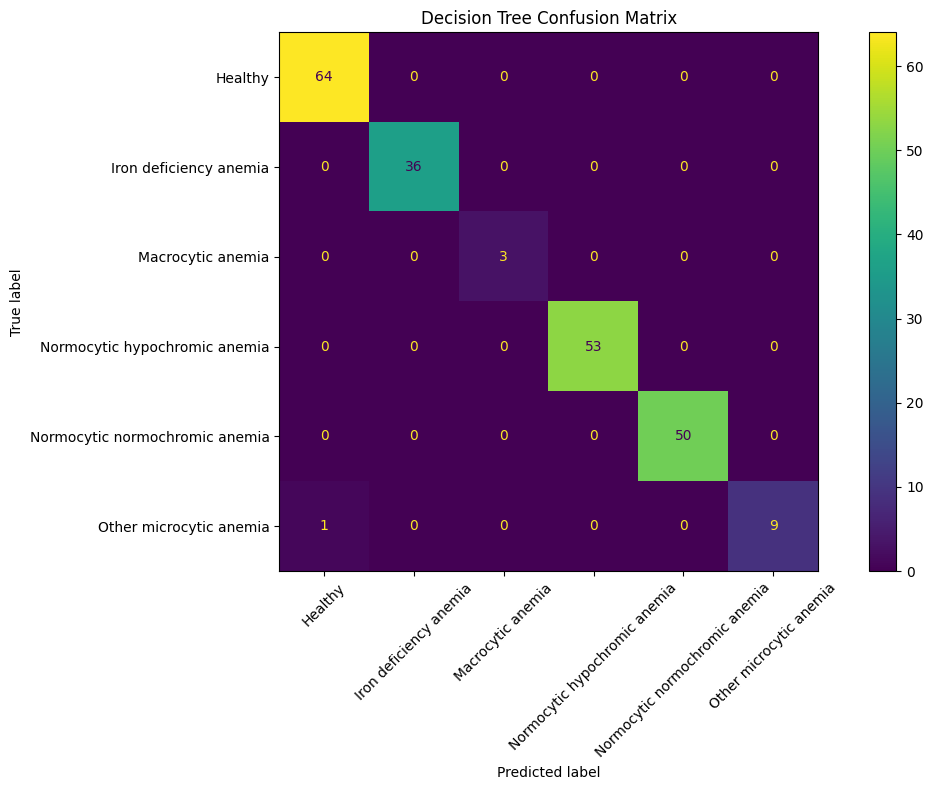

In [19]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(12, 8))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    dt_predictions,
    xticks_rotation=45,
    ax=ax
)

plt.title("Decision Tree Confusion Matrix")
plt.tight_layout()
plt.show()

### Confusion Matrix Interpretation

The final Decision Tree classifier correctly classified 215 out of 216
samples in the testing dataset.

All test samples belonging to Iron deficiency anemia, Macrocytic anemia,
Normocytic hypochromic anemia, and Normocytic normochromic anemia were
correctly classified.

One sample belonging to the Other microcytic anemia class was misclassified
as Healthy. This class contains relatively fewer samples compared with the
majority diagnosis classes.

Overall, the confusion matrix demonstrates strong class-wise classification
performance across the six diagnosis categories.

## Final Model Training and Export

After model comparison and evaluation, the selected Decision Tree classifier
is retrained using the complete cleaned anemia dataset.

The final trained model is exported along with the ordered feature list used
during training.

These files can later be integrated into the Blood Report Parser application
to classify extracted CBC parameters into the supported anemia diagnosis
categories.

In [20]:
import joblib

final_anemia_model = DecisionTreeClassifier(
    class_weight="balanced",
    random_state=42
)

final_anemia_model.fit(X, y)

joblib.dump(
    final_anemia_model,
    "anemia_decision_tree_model.pkl"
)

joblib.dump(
    selected_features,
    "anemia_feature_list.pkl"
)

print("Final anemia model saved successfully.")
print("Model file: anemia_decision_tree_model.pkl")
print("Feature file: anemia_feature_list.pkl")
print("Features:", selected_features)

Final anemia model saved successfully.
Model file: anemia_decision_tree_model.pkl
Feature file: anemia_feature_list.pkl
Features: ['WBC', 'RBC', 'HGB', 'MCV', 'MCH', 'MCHC', 'PLT']


## Verification of the Exported Model

The exported Decision Tree model and feature list are loaded from the saved
files to verify that the model can be used independently after training.

A sample CBC record is passed to the loaded model using the same ordered
features used during model training.

This step verifies the model export and prediction workflow required for
integration with the Blood Report Parser application.

In [21]:
loaded_model = joblib.load(
    "anemia_decision_tree_model.pkl"
)

loaded_features = joblib.load(
    "anemia_feature_list.pkl"
)

sample_cbc = pd.DataFrame(
    [[7.2, 3.97, 9.0, 77.0, 22.6, 29.5, 148.0]],
    columns=loaded_features
)

prediction = loaded_model.predict(sample_cbc)

print("CBC Input:")
print(sample_cbc)

print("\nPredicted Diagnosis:")
print(prediction[0])

CBC Input:
   WBC   RBC  HGB   MCV   MCH  MCHC    PLT
0  7.2  3.97  9.0  77.0  22.6  29.5  148.0

Predicted Diagnosis:
Iron deficiency anemia


In [22]:
import os

print(os.listdir("/kaggle/working"))

['anemia_decision_tree_model.pkl', '.virtual_documents', 'anemia_feature_list.pkl']
